In [1]:
!pip install gdown
!gdown "https://drive.google.com/uc?id=1DJ4Ltx9nvA_n-VPfZvk8qHGDBg-hNbY5"

Downloading...
From (original): https://drive.google.com/uc?id=1DJ4Ltx9nvA_n-VPfZvk8qHGDBg-hNbY5
From (redirected): https://drive.google.com/uc?id=1DJ4Ltx9nvA_n-VPfZvk8qHGDBg-hNbY5&confirm=t&uuid=e43f3007-a240-4e0a-b18c-e731d77bb740
To: /kaggle/working/Dataset.zip
100%|██████████████████████████████████████| 2.47G/2.47G [00:24<00:00, 99.1MB/s]


In [2]:
import zipfile
with zipfile.ZipFile("Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("./dataset")

In [14]:
import os
import pandas as pd
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from skimage.feature import graycomatrix, graycoprops
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
from copy import deepcopy
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from prettytable import PrettyTable
import time
from torchvision.models import resnet50, ResNet50_Weights

In [4]:
IMAGES_DIR = os.path.join("./dataset", "images-224/images-224")
LABELS_FILE = os.path.join("./dataset", "Data_Entry_2017.csv")

In [5]:
labels_data = pd.read_csv(LABELS_FILE)
all_labels = []
for label_str in labels_data['Finding Labels'].unique():
    all_labels.extend([l.strip() for l in label_str.split('|')])
DISEASE_LABELS = sorted(list(set(all_labels)))
print(f"Found {len(DISEASE_LABELS)} unique disease labels:")
print(DISEASE_LABELS)

Found 15 unique disease labels:
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [6]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_dir, row['Image Index'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image)

        labels = np.zeros(len(DISEASE_LABELS))
        for label in row['Finding Labels'].split('|'):
            if label in DISEASE_LABELS:
                labels[DISEASE_LABELS.index(label)] = 1

        return image, torch.FloatTensor(labels)

In [8]:
class GLCM_Features:
    def __init__(self, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
        self.distances = distances
        self.angles = angles

    def extract_features(self, image):
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        image = ((image - image.min()) * 255 / (image.max() - image.min())).astype(np.uint8)
        glcm = graycomatrix(image, self.distances, self.angles, symmetric=True, normed=True)
        features = []
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
            features.append(graycoprops(glcm, prop).mean())
        return torch.tensor(features)

In [37]:
class ResNetGLCM(nn.Module):
    def __init__(self, num_classes=15):
        super(ResNetGLCM, self).__init__()
        self.resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.resnet.fc = nn.Identity()
        self.glcm_features = GLCM_Features()
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 5, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x, glcm):
        cnn_features = self.resnet(x)
        combined = torch.cat((cnn_features, glcm), dim=1)
        output = self.classifier(combined)
        return output

In [38]:
train_len = int(0.64 * len(labels_data))
val_len = int(0.16 * len(labels_data))
test_len = len(labels_data) - train_len - val_len
train_df, val_df, test_df = random_split(labels_data, [train_len, val_len, test_len])

train_dataset = ChestXrayDataset(train_df.dataset, IMAGES_DIR, transform)
val_dataset = ChestXrayDataset(val_df.dataset, IMAGES_DIR, transform)
test_dataset = ChestXrayDataset(test_df.dataset, IMAGES_DIR, transform)

In [39]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetGLCM(num_classes=len(DISEASE_LABELS)).to(device)
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [41]:
def calc_mean_auc(labels: torch.tensor, preds: torch.tensor):
    labels = labels.cpu().detach().numpy()
    preds = preds.cpu().detach().numpy()

    per_class_auroc = []
    for i, name in enumerate(DISEASE_LABELS):
        try:
            per_class_auroc.append(roc_auc_score(labels[:, i], preds[:, i]))
        except ValueError:
            pass

    mean_roc_auc = np.array(per_class_auroc).mean()
    return mean_roc_auc

In [42]:
best_auroc = 0.0
patience = 2 
patience_counter = 0
table = PrettyTable(field_names=["Epoch", "Train Loss", "Val Loss", "Val AUROC"])

for epoch in range(10):
    start_time = time.time()

    train_loss = 0.0
    val_loss = 0.0
    epoch_auroc = 0.0

    for phase in ["train", "val"]:
        if phase == "train":
            model.train()
            data_loader = train_loader
        else:
            model.eval()
            data_loader = val_loader

        running_loss = 0.0
        all_labels, all_preds = [], []

        for images, labels in tqdm(data_loader):
            images, labels = images.to(device), labels.to(device)

            if phase == "train":
                optimizer.zero_grad()

            with torch.set_grad_enabled(phase == "train"):
                outputs = model(images, torch.zeros(images.size(0), 5).to(device))
                loss = criterion(outputs, labels)

                if phase == "train":
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * images.size(0)

            if phase == "val":
                all_labels.append(labels.cpu())
                all_preds.append(outputs.cpu())

        # Hitung loss per epoch
        epoch_loss = running_loss / len(data_loader.dataset)

        if phase == "train":
            train_loss = epoch_loss  
        else:
            val_loss = epoch_loss 
            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            epoch_auroc = calc_mean_auc(all_labels, all_preds)

            # Simpan model terbaik
            if epoch_auroc > best_auroc:
                best_auroc = epoch_auroc
                patience_counter = 0
                best_model_wts = deepcopy(model.state_dict())
                torch.save(best_model_wts, "best_model.pth")
            else:
                patience_counter += 1

    # Tambahkan satu row ke table
    table.add_row([
        epoch + 1,
        round(train_loss, 4),
        round(val_loss, 4),
        round(epoch_auroc, 4)
    ])
    print(table)

    # Scheduler step setelah validasi
    scheduler.step(val_loss)

    # Early Stopping
    if patience_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

    print(f"Epoch {epoch + 1} completed in {time.time() - start_time:.2f}s")

100%|██████████| 3504/3504 [03:45<00:00, 15.56it/s]


+-------+------------+----------+-----------+
| Epoch | Train Loss | Val Loss | Val AUROC |
+-------+------------+----------+-----------+
|   1   |   0.1911   |  0.1799  |   0.7992  |
+-------+------------+----------+-----------+
Epoch 1 completed in 821.05s


100%|██████████| 3504/3504 [03:41<00:00, 15.81it/s]


+-------+------------+----------+-----------+
| Epoch | Train Loss | Val Loss | Val AUROC |
+-------+------------+----------+-----------+
|   1   |   0.1911   |  0.1799  |   0.7992  |
|   2   |   0.1822   |  0.1784  |   0.8127  |
+-------+------------+----------+-----------+
Epoch 2 completed in 817.23s


100%|██████████| 3504/3504 [03:40<00:00, 15.87it/s]


...

+-------+------------+----------+-----------+
| Epoch | Train Loss | Val Loss | Val AUROC |
+-------+------------+----------+-----------+
|   1   |   0.1911   |  0.1799  |   0.7992  |
|   2   |   0.1822   |  0.1784  |   0.8127  |
|   3   |   0.179    |  0.1735  |   0.8243  |
|   4   |   0.1763   |  0.1703  |   0.8297  |
|   5   |   0.174    |  0.1682  |   0.8383  |
|   6   |   0.1715   |  0.1648  |   0.8468  |
|   7   |   0.1685   |  0.1599  |   0.8593  |
|   8   |   0.1651   |  0.1549  |   0.8727  |
+-------+------------+----------+-----------+
Epoch 8 completed in 816.06s


100%|██████████| 3504/3504 [03:40<00:00, 15.91it/s]


+-------+------------+----------+-----------+
| Epoch | Train Loss | Val Loss | Val AUROC |
+-------+------------+----------+-----------+
|   1   |   0.1911   |  0.1799  |   0.7992  |
|   2   |   0.1822   |  0.1784  |   0.8127  |
|   3   |   0.179    |  0.1735  |   0.8243  |
|   4   |   0.1763   |  0.1703  |   0.8297  |
|   5   |   0.174    |  0.1682  |   0.8383  |
|   6   |   0.1715   |  0.1648  |   0.8468  |
|   7   |   0.1685   |  0.1599  |   0.8593  |
|   8   |   0.1651   |  0.1549  |   0.8727  |
|   9   |   0.1612   |  0.1472  |   0.8862  |
+-------+------------+----------+-----------+
Epoch 9 completed in 815.77s


100%|██████████| 3504/3504 [03:39<00:00, 15.93it/s]


+-------+------------+----------+-----------+
| Epoch | Train Loss | Val Loss | Val AUROC |
+-------+------------+----------+-----------+
|   1   |   0.1911   |  0.1799  |   0.7992  |
|   2   |   0.1822   |  0.1784  |   0.8127  |
|   3   |   0.179    |  0.1735  |   0.8243  |
|   4   |   0.1763   |  0.1703  |   0.8297  |
|   5   |   0.174    |  0.1682  |   0.8383  |
|   6   |   0.1715   |  0.1648  |   0.8468  |
|   7   |   0.1685   |  0.1599  |   0.8593  |
|   8   |   0.1651   |  0.1549  |   0.8727  |
|   9   |   0.1612   |  0.1472  |   0.8862  |
|   10  |   0.1564   |  0.144   |   0.8941  |
+-------+------------+----------+-----------+
Epoch 10 completed in 815.68s


In [43]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        glcm_features = torch.zeros(images.size(0), 5).to(device)
        outputs = model(images, glcm_features)
        all_labels.append(labels.cpu())
        all_preds.append(outputs.cpu())

all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)

print("----- Per-Class AUROC -----")
for i, name in enumerate(DISEASE_LABELS):
    try:
        print(f"{name}: {roc_auc_score(all_labels[:, i], all_preds[:, i]):.4f}")
    except ValueError:
        print(f"{name}: N/A")

<ipython-input-43-51f7c802fd7a>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))
100%|██████████| 3504/3504 [03:39<00:00,

----- Per-Class AUROC -----
Atelectasis: 0.8974
Cardiomegaly: 0.9579
Consolidation: 0.8475
Edema: 0.9301
Effusion: 0.9247
Emphysema: 0.9529
Fibrosis: 0.8703
Hernia: 0.8874
Infiltration: 0.8110
Mass: 0.9336
No Finding: 0.8942
Nodule: 0.8841
Pleural_Thickening: 0.8547
Pneumonia: 0.8318
Pneumothorax: 0.9331


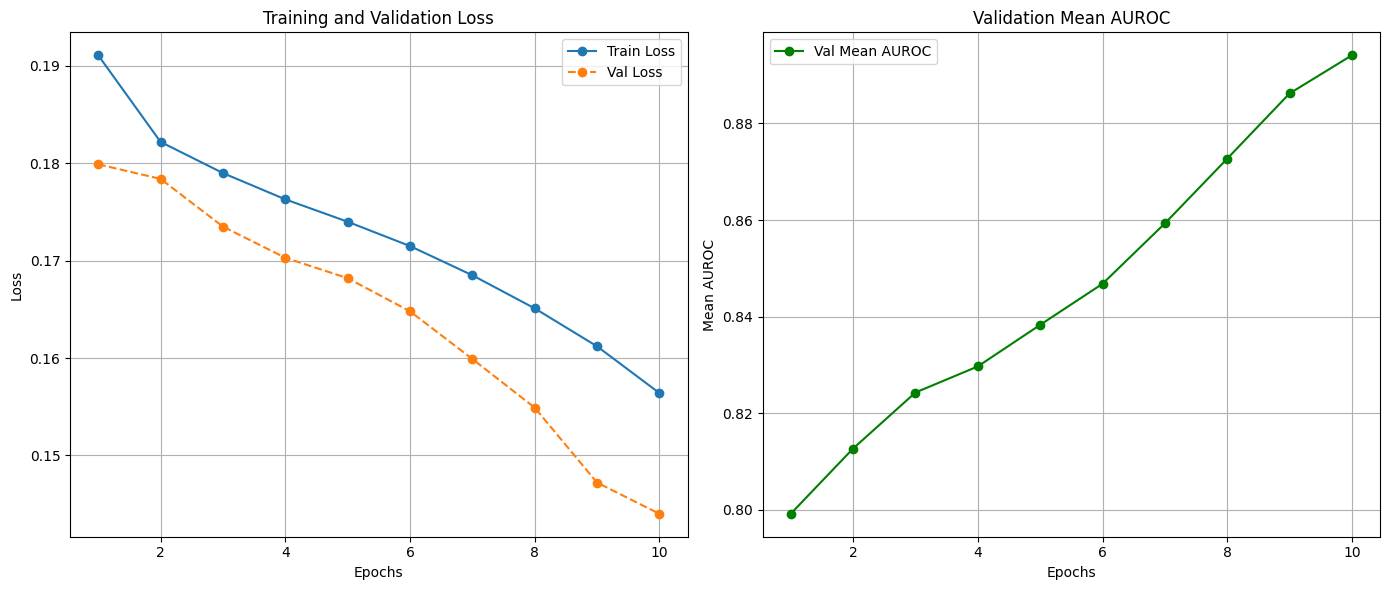

In [45]:
epochs = list(range(1, 11))
train_losses = [0.1911, 0.1822, 0.179, 0.1763, 0.174, 0.1715, 0.1685, 0.1651, 0.1612, 0.1564]
val_losses = [0.1799, 0.1784, 0.1735, 0.1703, 0.1682, 0.1648, 0.1599, 0.1549, 0.1472, 0.144]
val_aurocs = [0.7992, 0.8127, 0.8243, 0.8297, 0.8383, 0.8468, 0.8593, 0.8727, 0.8862, 0.8941]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss", marker="o")
plt.plot(epochs, val_losses, label="Val Loss", marker="o", linestyle="--")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_aurocs, label="Val Mean AUROC", marker="o", color="green")
plt.title("Validation Mean AUROC")
plt.xlabel("Epochs")
plt.ylabel("Mean AUROC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()